# Multiple Orbits

galpy's `Orbit` class natively handles multiple orbits at once,
enabling efficient parallel integration and vectorized access to
orbital quantities.

For basic orbit initialization, see [Orbit Initialization](initialization.ipynb).

In [1]:
%matplotlib inline
import numpy
from astropy import units
from astropy.coordinates import SkyCoord
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Array initialization

Pass a 2D array of shape `(N, dim)` to create N orbits at once.

In [2]:
numpy.random.seed(42)
N = 10
vxvvs = numpy.column_stack(
    [
        numpy.random.uniform(0.8, 1.2, N),  # R
        numpy.random.normal(0.0, 0.05, N),  # vR
        numpy.random.uniform(0.9, 1.1, N),  # vT
        numpy.random.normal(0.0, 0.05, N),  # z
        numpy.random.normal(0.0, 0.05, N),  # vz
        numpy.random.uniform(0.0, 2 * numpy.pi, N),  # phi
    ]
)
os = Orbit(vxvvs)
print("Number of orbits:", os.size)
print("Shape:", os.shape)
print("R values:", os.R())

Number of orbits: 10
Shape: (10,)
R values: [0.94981605 1.18028572 1.09279758 1.03946339 0.86240746 0.86239781
 0.82323344 1.14647046 1.040446   1.08322903]


Orbits can have arbitrary shapes that are preserved for all outputs. For example, to create a 2D grid of orbits, we can do:

In [3]:
numpy.random.seed(42)
N, M = 10, 5
vxvvs_2d = numpy.stack(
    [
        numpy.random.uniform(0.8, 1.2, size=(N, M)),  # R
        numpy.random.normal(0.0, 0.05, size=(N, M)),  # vR
        numpy.random.uniform(0.9, 1.1, size=(N, M)),  # vT
        numpy.random.normal(0.0, 0.05, size=(N, M)),  # z
        numpy.random.normal(0.0, 0.05, size=(N, M)),  # vz
        numpy.random.uniform(0.0, 2 * numpy.pi, size=(N, M)),  # phi
    ],
    axis=-1,
)
os = Orbit(vxvvs_2d)
print("Number of orbits:", os.size)
print("Shape:", os.shape)
print("R values:", os.R())

Number of orbits: 50
Shape: (10, 5)
R values: [[0.94981605 1.18028572 1.09279758 1.03946339 0.86240746]
 [0.86239781 0.82323344 1.14647046 1.040446   1.08322903]
 [0.8082338  1.18796394 1.13297706 0.88493564 0.87272999]
 [0.8733618  0.9216969  1.00990257 0.97277801 0.91649166]
 [1.04474116 0.85579754 0.91685786 0.94654474 0.98242799]
 [1.11407038 0.87986951 1.00569378 1.03696583 0.81858017]
 [1.04301794 0.86820965 0.82602064 1.17955421 1.18625281]
 [1.12335894 0.92184551 0.83906885 1.07369321 0.976061  ]
 [0.84881529 0.99807076 0.81375541 1.16372816 0.90351199]
 [1.06500891 0.92468443 1.00802721 1.01868411 0.87394178]]


## Initialization from SkyCoord arrays

You can pass a `SkyCoord` containing multiple objects.

In [4]:
sc = SkyCoord(
    ra=[20.0, 50.0, 100.0] * units.deg,
    dec=[30.0, -10.0, 45.0] * units.deg,
    distance=[1.5, 3.0, 0.8] * units.kpc,
    pm_ra_cosdec=[3.5, -1.0, 2.0] * units.mas / units.yr,
    pm_dec=[-1.2, 0.5, -0.3] * units.mas / units.yr,
    radial_velocity=[15.0, -30.0, 50.0] * units.km / units.s,
)
os_sc = Orbit(sc)
print("Number of orbits:", os_sc.size)
print("RA values:", os_sc.ra())

Number of orbits: 3
RA values: [ 20.  50. 100.]


## List initialization

A list of phase-space arrays also works.

In [5]:
os_list = Orbit(
    [
        [1.0, 0.1, 1.0, 0.0, 0.05, 0.0],
        [0.9, -0.05, 1.1, 0.02, -0.03, 1.0],
    ]
)
print("Size:", os_list.size)
print("R:", os_list.R())

Size: 2
R: [1.  0.9]


or a list or Orbit instances, e.g.:

In [6]:
os_list = Orbit(
    [
        Orbit([1.0, 0.1, 1.0, 0.0, 0.05, 0.0]),
        Orbit([0.9, -0.05, 1.1, 0.02, -0.03, 1.0]),
    ]
)
print("Size:", os_list.size)
print("R:", os_list.R())

Size: 2
R: [1.  0.9]


## Shape, len, size, and reshape

Multi-orbit objects behave like arrays.

In [7]:
os_many = Orbit(vxvvs)
print("len:", len(os_many))
print("size:", os_many.size)
print("shape:", os_many.shape)

# Reshape to (2, 5) -- reshape is done in-place
os_many.reshape((2, 5))
print("Reshaped shape:", os_many.shape)
print("Reshaped len:", len(os_many))

len: 10
size: 10
shape: (10,)
Reshaped shape: (2, 5)
Reshaped len: 2


## Slicing and indexing

Indexing and slicing returns a new `Orbit` object.

In [8]:
# Single orbit (from the flat os object)
os_flat = Orbit(vxvvs)
o_single = os_flat[3]
print("Single orbit:", o_single)
print("Size:", o_single.size)

# Slice
o_slice = os_flat[2:5]
print("Slice size:", o_slice.size)

# 2D indexing on reshaped
o_2d = os_many[1, 2]
print("2D indexed orbit R:", o_2d.R())

Single orbit: <galpy.orbit.Orbits.Orbit object at 0x7ff0e3e43450>
Size: 1
Slice size: 3
2D indexed orbit R: 1.146470458309974


## Output shapes are preserved

When you access quantities from a multi-orbit object, the output
has the same shape as the orbit array.

In [9]:
print("R shape (flat):", os_flat.R().shape)
print("R shape (reshaped):", os_many.R().shape)

R shape (flat): (10,)
R shape (reshaped): (2, 5)


## Array-valued Solar parameters

You can pass arrays for `ro`, `zo`, and `vo`, as well as an array-valued
`solarmotion`, when initializing multiple orbits from observed coordinates.
This is useful when propagating uncertainty in Solar parameters across many
orbit realizations.

The scalar-parameter arrays should have the same shape as the orbit array.
For a one-dimensional orbit array of length `N`, `solarmotion` should have
shape `(3, N)`.

In [10]:
lb_data = numpy.tile([20.0, 30.0, 2.0, -10.0, 20.0, 50.0], (3, 1))
solarmotion = numpy.array(
    [
        [10.0, 11.0, 12.0],
        [11.0, 12.0, 13.0],
        [7.0, 7.5, 8.0],
    ]
)
os_phys = Orbit(
    lb_data,
    lb=True,
    ro=numpy.array([8.0, 8.2, 8.4]),
    zo=numpy.array([0.015, 0.0208, 0.03]),
    vo=numpy.array([220.0, 225.0, 230.0]),
    solarmotion=solarmotion,
)
print("R (physical):", os_phys.R())
print("z (physical):", os_phys.z())
print("vR (physical):", os_phys.vR())

R (physical): [6.39801729 6.5965276  6.79471746]
z (physical): [1.01194971 1.01667146 1.02418402]
vR (physical): [37.01873757 38.08904318 39.07811118]


## Integrating and plotting multiple orbits

When integrating multiple orbits, output array have an additional `T` dimension with `T` the number of time steps. This allows you to easily access the integrated trajectories of all orbits.

When plotting multiple orbits, each orbit is plotted with a different color by default.

Integrated shape: (10, 1001)


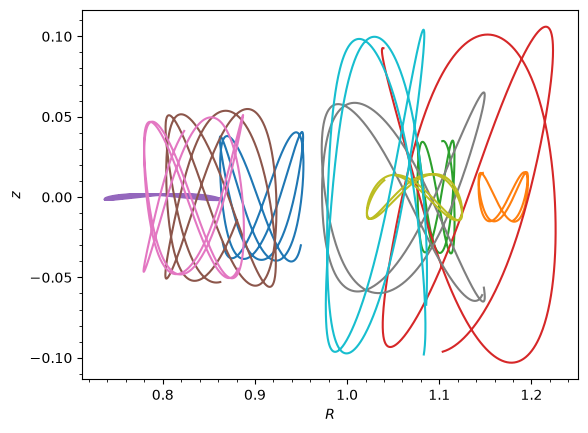

In [11]:
from matplotlib import pyplot as plt

# Integrate all 10 orbits and plot them
os_plot = Orbit(vxvvs)
ts = numpy.linspace(0.0, 10.0, 1001)
os_plot.integrate(ts, MWPotential2014)
print("Integrated shape:", os_plot.R(ts).shape)
os_plot.plot();

When slicing or indexing a multi-orbit object, the resulting single orbit object retains the integrated trajectory of the original multi-orbit object, so you can still plot it without re-integrating:

Shape of os_plot[1].R(ts): (1001,)
Shape of os_plot[3:9].R(ts): (6, 1001)


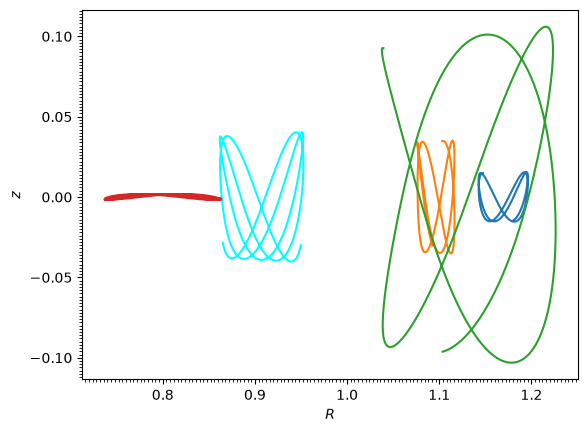

In [12]:
print(f"Shape of os_plot[1].R(ts): {os_plot[1].R(ts).shape}")
print(f"Shape of os_plot[3:9].R(ts): {os_plot[3:9].R(ts).shape}")
os_plot[0].plot(color="cyan")  # Plot the first orbit in a different color
os_plot[1:5].plot(overplot=True)  # Plot orbits 1-4 in default colors
plt.gca().autoscale();

## Per-orbit integration time arrays

By default, `Orbit.integrate(t, pot)` uses a single shared time array `t` for every orbit in the instance. You can also pass per-orbit time arrays by giving `t` a shape that matches the `Orbit` shape with an additional time axis at the end — i.e. `(*orbit.shape, nt)`. Each orbit is then integrated on its own time grid, while still benefiting from the batched, multi-threaded C integrator.

This is useful when each orbit has a natural integration window of its own, e.g. tail particles in a tidal stream, each integrated from its individual stripping time to the present.

Note that orbit-continuation (re-integrating to extend an already-integrated orbit) is not supported in this mode — each call to ``integrate`` with a per-orbit ``t`` restarts from the original initial conditions.

In [13]:
os_indiv = Orbit(vxvvs)  # 10 orbits
# Each orbit gets its own time grid; here from 0 to t_end[i]
t_end = numpy.linspace(5.0, 12.0, os_indiv.size)
ts_indiv = numpy.linspace(
    numpy.zeros(os_indiv.size), t_end, 1001, axis=-1
)  # shape (10, 1001)
os_indiv.integrate(ts_indiv, MWPotential2014, method="dop853_c")
print("orbit storage shape:", os_indiv.orbit.shape)
print("per-orbit time-array shape:", os_indiv.t.shape)

orbit storage shape: (10, 1001, 6)
per-orbit time-array shape: (10, 1001)
